In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/fake reviews dataset.csv")
print(df.head())
print(df.shape)

             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  
(40432, 4)


In [ ]:
print(df.info())
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB
None
label
CG    20216
OR    20216
Name: count, dtype: int64


In [ ]:
#basic Formatting
df['text_'] = df['text_'].str.strip()
df['text_'] = df['text_'].str.lower()
df['text_'] = df['text_'].str.replace('[{}]'.format(string.punctuation), '')

df = df.dropna(subset=['text_', 'category', 'rating', 'label'])

#labeling
df['label'] = df['label'].map({'OR': 0, 'CG': 1})

# Check dataset
print(f"Total clean records: {len(df)}")
print("\nTarget Variable Distribution (Checking for 50/50 balance):")
print(df['label'].value_counts(normalize=True))

Total clean records: 40432

Target Variable Distribution (Checking for 50/50 balance):
label
1    0.5
0    0.5
Name: proportion, dtype: float64


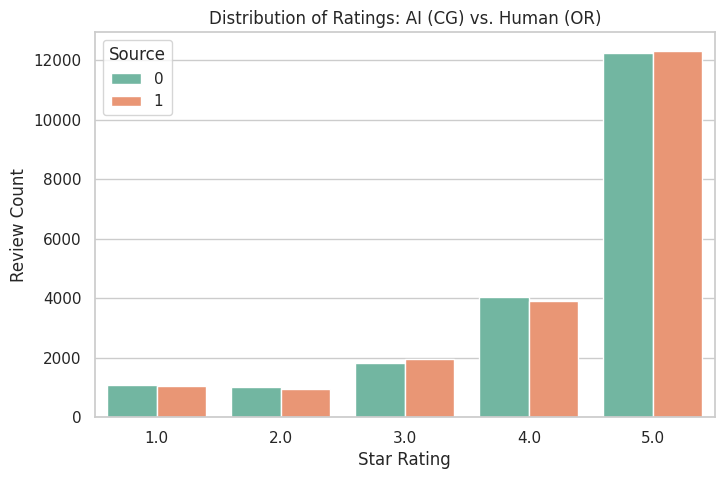

In [ ]:
#rating dist
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='rating', hue='label', palette='Set2')
plt.title('Distribution of Ratings: AI (CG) vs. Human (OR)')
plt.xlabel('Star Rating')
plt.ylabel('Review Count')
plt.legend(title='Source')
plt.show()

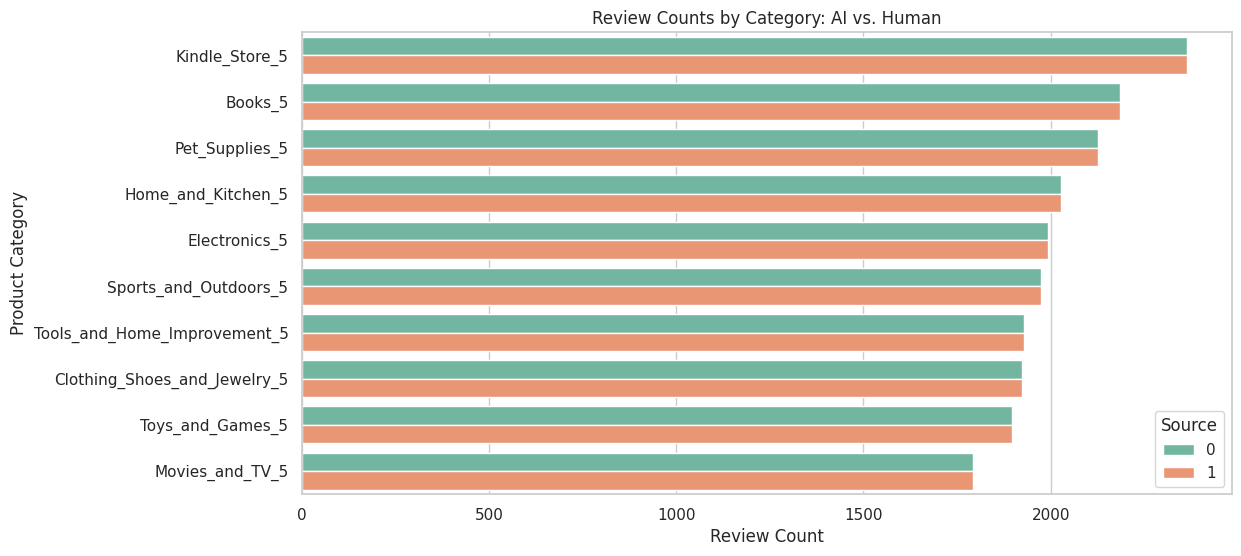

In [ ]:
#category dist
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='category', hue='label', palette='Set2', order=df['category'].value_counts().index)
plt.title('Review Counts by Category: AI vs. Human')
plt.xlabel('Review Count')
plt.ylabel('Product Category')
plt.legend(title='Source')
plt.show()

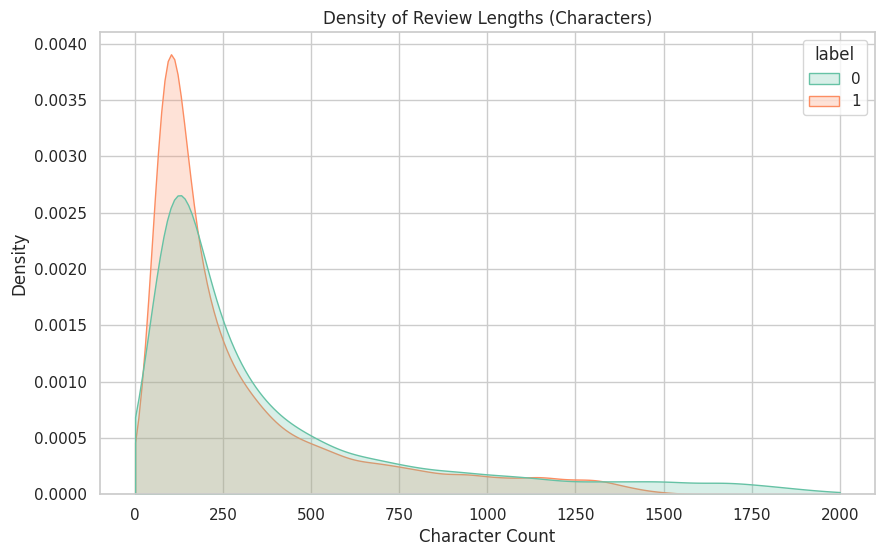

In [ ]:
#text length analysis
# Calculate character count for this visualization
df['char_count'] = df['text_'].apply(len)

plt.figure(figsize=(10, 6))
# Using a KDE (Kernel Density Estimate) plot to see the shape of the distribution
sns.kdeplot(data=df, x='char_count', hue='label', common_norm=False, fill=True, palette='Set2', clip=(0, 2000))
plt.title('Density of Review Lengths (Characters)')
plt.xlabel('Character Count')
plt.ylabel('Density')
plt.show()

In [ ]:
#train-test-split for BERT/RoBERTa models
from sklearn.model_selection import train_test_split
df.drop(columns =['category', 'rating'] , inplace=True)

df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

# 2. Save these raw splits for Notebook A (The RoBERTa Semantic Branch)
df_train.to_csv('train_text_data.csv', index=False)
df_test.to_csv('test_text_data.csv', index=False)

print("Saved raw data splits for BERT/RoBERTa branch.")

Saved raw data splits for BERT/RoBERTa branch.


In [ ]:
#train-test-split for XGBoost

def extract_statistical_features(data):
    df_feat = data.copy()
    df_feat['char_count'] = df_feat['text_'].apply(len)
    df_feat['word_count'] = df_feat['text_'].apply(lambda x: len(str(x).split()))
    df_feat['punct_density'] = df_feat['text_'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]) / (len(str(x)) + 1))
    df_feat['cap_ratio'] = df_feat['text_'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))
    return df_feat[['char_count', 'word_count', 'punct_density', 'cap_ratio', 'rating', 'category', 'label']]

# 1. Extract Features
df_num = extract_statistical_features(df)

#train-test-split
df_train_num, df_test_num = train_test_split(df_num, test_size=0.2, stratify=df['label'], random_state=42)

#saving the files
df_train_num.to_csv('train_num_data.csv', index=False)
df_test_num.to_csv('test_num_data.csv', index=False)

print("Saved raw data splits for Classiscal ML branch.")

Saved raw data splits for Classiscal ML branch.
